In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Data/data_preprocessing.csv', index_col='Date', parse_dates=True)
df.head()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88


In [3]:
# Sắp xếp và kiểm tra dữ liệu
df = df.sort_index()

# kiểm tra liên tục thời gian
print(df.index.to_series().diff().value_counts().head())

Date
1 days    12204
Name: count, dtype: int64


In [4]:
# Chọn biến đầu vào & mục tiêu
features = ['Precipitation', 'Relative Humidity', 'Wind Speed']
target = 'Temperature'

X = df[features]
y = df[target]

In [5]:
# Chia tập dữ liệu: 70% train, 15% validation, 15% test
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8543, 3)
y_train shape: (8543,)
X_val shape: (1830, 3)
y_val shape: (1830,)
X_test shape: (1832, 3)
y_test shape: (1832,)


In [7]:
# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

In [8]:
# Hàm tạo chuỗi dữ liệu > Dự đoán ngày tiếp theo
def create_sequences(X, y, time_step):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_step):
        X_seq.append(X[i:i + time_step])
        y_seq.append(y[i + time_step])
        
    return np.array(X_seq), np.array(y_seq)

In [9]:
# Xác định time_step = 30 
time_step = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_step)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, time_step)

In [10]:
# Khai báo thư viện
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

In [11]:
# Khởi tạo lớp LTCCell 
from keras.saving import register_keras_serializable

@register_keras_serializable()
class LTCCell(layers.Layer):
    def __init__(self, units, **kwargs):
        super(LTCCell, self).__init__(**kwargs)
        self.units = units
    # Khai báo state_size & output_size
    @property
    def state_size(self): # Kích thước trạng thái ẩn
        return self.units
    @property
    def output_size(self): # Kích thước đầu ra
        return self.units
    # Tạo các tham số (weights)
    def build(self, input_shape):
        input_dim = int(input_shape[-1])
# Trọng số cho input
        self.W = self.add_weight(
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='kernel_W'
        )
# Trọng số hồi quy
        self.U = self.add_weight(
            shape=(self.units, self.units),
            initializer='orthogonal',
            trainable=True,
            name='recurrent_kernel_U'
        )
# Bias
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias_b'
        )
# Tham số τ (time constant) 
# τ lớn → cập nhật chậm
# τ nhỏ → cập nhật nhanh
        self.tau = self.add_weight(
            shape=(self.units,),
            initializer='ones',
            trainable=True,
            name='time_constant_tau'
        )
# Hệ số khuếch đại
        self.gain = self.add_weight(
            shape=(self.units,),
            initializer='ones',
            trainable=True,
            name='gain'
        )
        super(LTCCell, self).build(input_shape)
        # Hàm cập nhật trạng thái (call)
    def call(self, inputs, states):
        prev_output = states[0] 
# Tính h = Wx + Uh + b
        h = tf.matmul(inputs, self.W) + tf.matmul(prev_output, self.U) + self.b
# Giới hạn τ để tránh giá trị quá lớn/nhỏ
        tau_clipped = tf.clip_by_value(self.tau, 0.1, 10.0)
# α = 1/τ
        alpha = 1.0 / tau_clipped
# Hàm kích hoạt
        activation = tf.tanh(self.gain * h)
# Công thức cập nhật động học liên tục
        output = (1 - alpha) * prev_output + alpha * activation
        return output, [output]

In [12]:
from tensorflow.keras.models import load_model

model_lnn = load_model(
    "temperature_lnn_model.keras",
    custom_objects={"LTCCell": LTCCell}
)
model_cnn  = load_model("temperature_cnn_1D_model.keras")
model_lstm = load_model("temperature_lstm_model.keras")
model_gru  = load_model("temperature_gru_model.keras")
model_lnn  = load_model("temperature_lnn_model.keras", custom_objects={"LTCCell": LTCCell})

In [13]:
y_pred_cnn  = scaler_y.inverse_transform(model_cnn.predict(X_test_seq))
y_pred_lstm = scaler_y.inverse_transform(model_lstm.predict(X_test_seq))
y_pred_gru  = scaler_y.inverse_transform(model_gru.predict(X_test_seq))
y_pred_lnn  = scaler_y.inverse_transform(model_lnn.predict(X_test_seq))

y_test_original = scaler_y.inverse_transform(y_test_seq)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step  
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step   
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mse, rmse, mae, r2, mape

In [15]:
results = {}
results["CNN-1D"] = evaluate_model(y_test_original, y_pred_cnn)
results["LSTM"]   = evaluate_model(y_test_original, y_pred_lstm)
results["GRU"]    = evaluate_model(y_test_original, y_pred_gru)
results["LNN"]    = evaluate_model(y_test_original, y_pred_lnn)

In [16]:
comparison_df = pd.DataFrame(results, 
                             index=["MSE", "RMSE", "MAE", "R²", "MAPE (%)"]).T
comparison_df.round(4)

,MSE,RMSE,MAE,R²,MAPE (%)
CNN-1D,1.7736,1.3318,1.0461,0.3356,3.9681
LSTM,1.2114,1.1006,0.8449,0.5462,3.2014
GRU,1.5563,1.2475,1.0115,0.4170,3.7929
LNN,1.5871,1.2598,0.9918,0.4055,3.7325


<Axes: >

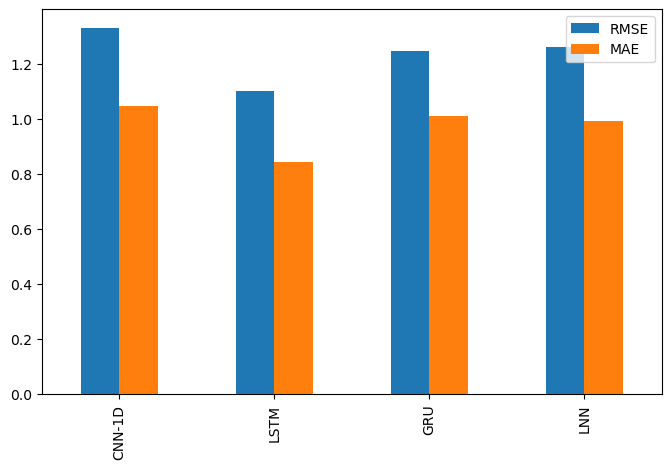

In [17]:
comparison_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(8,5))

<Figure size 800x500 with 0 Axes>

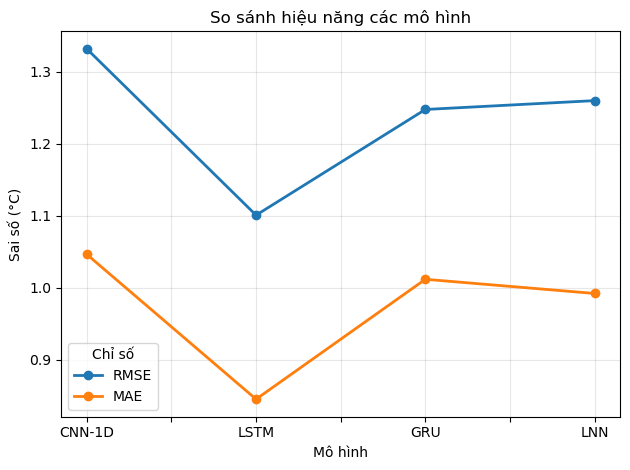

In [18]:
plt.figure(figsize=(8,5))

ax = comparison_df[["RMSE", "MAE"]].plot(
    marker="o",
    linewidth=2
)

plt.title("So sánh hiệu năng các mô hình")
plt.ylabel("Sai số (°C)")
plt.xlabel("Mô hình")
plt.xticks(rotation=0)
plt.legend(title="Chỉ số")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

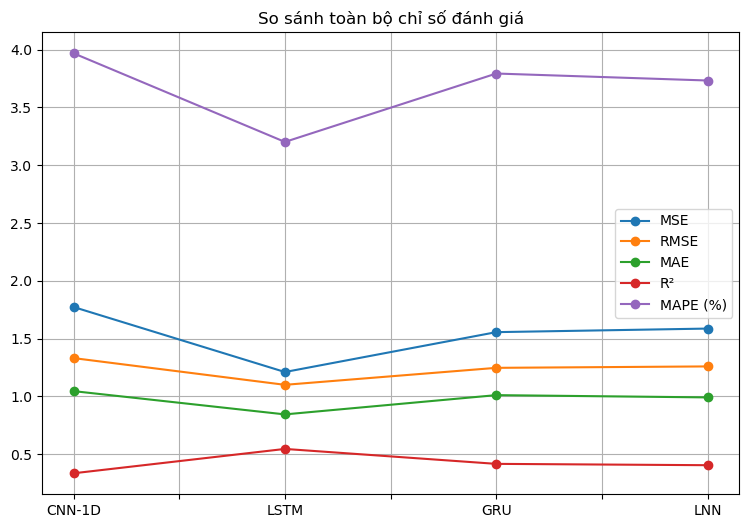

In [19]:
comparison_df.plot(
    kind="line",
    marker="o",
    figsize=(9,6)
)

plt.title("So sánh toàn bộ chỉ số đánh giá")
plt.grid(True)
plt.show()